In [5]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [6]:
# data
def load_and_display_data(file_path="winequality-red.csv", sample_size=20):
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

    try:
        df_red = pd.read_csv(file_path, sep=";")
        print(f"Data loaded from local file: {file_path}")
    except FileNotFoundError:
        df_red = pd.read_csv(url, sep=";")
        print("Local file not found. Data loaded from UCI online source.")

    print("\nDataset shape:")
    print(df_red.shape)

    print("\nSample data:")
    print(df_red.sample(sample_size, random_state=0))

    return df_red


df_red = load_and_display_data()

features = df_red.drop("quality", axis=1).columns.tolist()

X_red = df_red[features]
y_red = df_red["quality"]


# preprocessing

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power_transform", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, features)
])



# cross-validation setup

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=0
)

Local file not found. Data loaded from UCI online source.

Dataset shape:
(1599, 12)

Sample data:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1109           10.8             0.470         0.43            2.10      0.171   
1032            8.1             0.820         0.00            4.10      0.095   
1002            9.1             0.290         0.33            2.05      0.063   
487            10.2             0.645         0.36            1.80      0.053   
979            12.2             0.450         0.49            1.40      0.075   
1054            8.2             0.640         0.27            2.00      0.095   
542             9.3             0.715         0.24            2.10      0.070   
853             9.3             0.360         0.39            1.50      0.080   
1189            8.8             0.955         0.05            1.80      0.075   
412             7.1             0.735         0.16            1.90      0.100   
1099      

In [7]:
### Models###
# RF no preprocessing


rf_no_preprocessing = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight="balanced"
)

rf_scores_no_preprocessing = cross_val_score(
    rf_no_preprocessing,
    X_red,
    y_red,
    cv=cv,
    scoring="accuracy"
)

print(
    "\nRF without preprocessing mean score: {:.4f}".format(
        rf_scores_no_preprocessing.mean()
    )
)



# RF with preprocessing

rf_with_preprocessing = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=0,
        class_weight="balanced"
    ))
])

rf_scores_with_preprocessing = cross_val_score(
    rf_with_preprocessing,
    X_red,
    y_red,
    cv=cv,
    scoring="accuracy"
)

print(
    "RF with preprocessing mean score: {:.4f}".format(
        rf_scores_with_preprocessing.mean()
    )
)


# KNN no preprocessing


knn_no_preprocessing = KNeighborsClassifier(
    n_neighbors=15
)

knn_scores_no_preprocessing = cross_val_score(
    knn_no_preprocessing,
    X_red,
    y_red,
    cv=cv,
    scoring="accuracy"
)

print(
    "KNN without preprocessing mean score: {:.4f}".format(
        knn_scores_no_preprocessing.mean()
    )
)



# KNN with preprocessing

knn_with_preprocessing = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=15
    ))
])

knn_scores_with_preprocessing = cross_val_score(
    knn_with_preprocessing,
    X_red,
    y_red,
    cv=cv,
    scoring="accuracy"
)

print(
    "KNN with preprocessing mean score: {:.4f}".format(
        knn_scores_with_preprocessing.mean()
    )
)


# Summary


results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest",
        "KNN",
        "KNN"
    ],
    "Preprocessing": [
        "No",
        "Yes",
        "No",
        "Yes"
    ],
    "Mean Accuracy": [
        rf_scores_no_preprocessing.mean(),
        rf_scores_with_preprocessing.mean(),
        knn_scores_no_preprocessing.mean(),
        knn_scores_with_preprocessing.mean()
    ],
    "Standard Deviation": [
        rf_scores_no_preprocessing.std(),
        rf_scores_with_preprocessing.std(),
        knn_scores_no_preprocessing.std(),
        knn_scores_with_preprocessing.std()
    ]
})

print("\nSummary Results:")
print(results)



RF without preprocessing mean score: 0.7123
RF with preprocessing mean score: 0.7123
KNN without preprocessing mean score: 0.5016
KNN with preprocessing mean score: 0.6173

Summary Results:
           Model Preprocessing  Mean Accuracy  Standard Deviation
0  Random Forest            No       0.712323            0.043639
1  Random Forest           Yes       0.712331            0.043231
2            KNN            No       0.501568            0.035281
3            KNN           Yes       0.617296            0.038613


In [8]:
### confg###
# color


soft_blue = "#8ECAE6"
soft_teal = "#A8DADC"
soft_green = "#B7E4C7"
soft_orange = "#FFD6A5"
soft_purple = "#CDB4DB"
soft_pink = "#FFC8DD"
soft_gray = "#D9D9D9"
soft_red = "#FFADAD"

model_colors = [
    soft_blue,
    soft_teal,
    soft_orange,
    soft_green
]


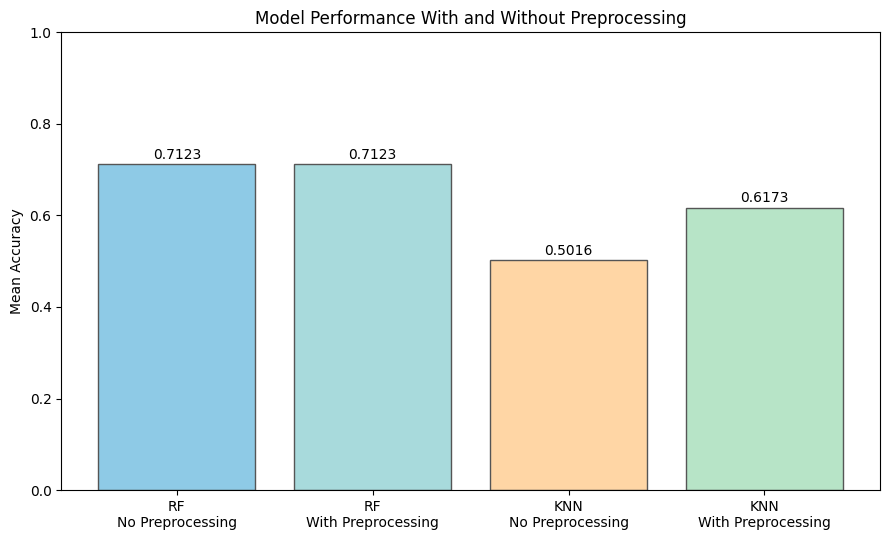

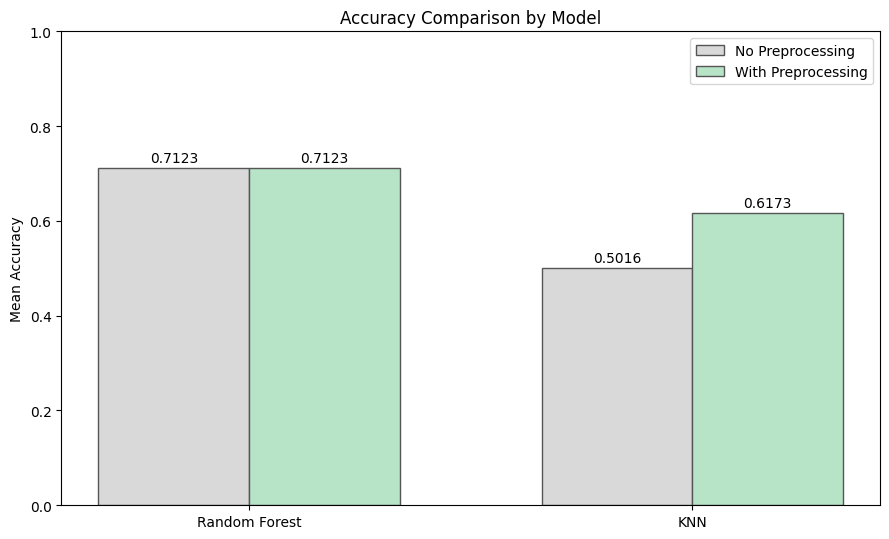

/tmp/ipykernel_5852/1105533313.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


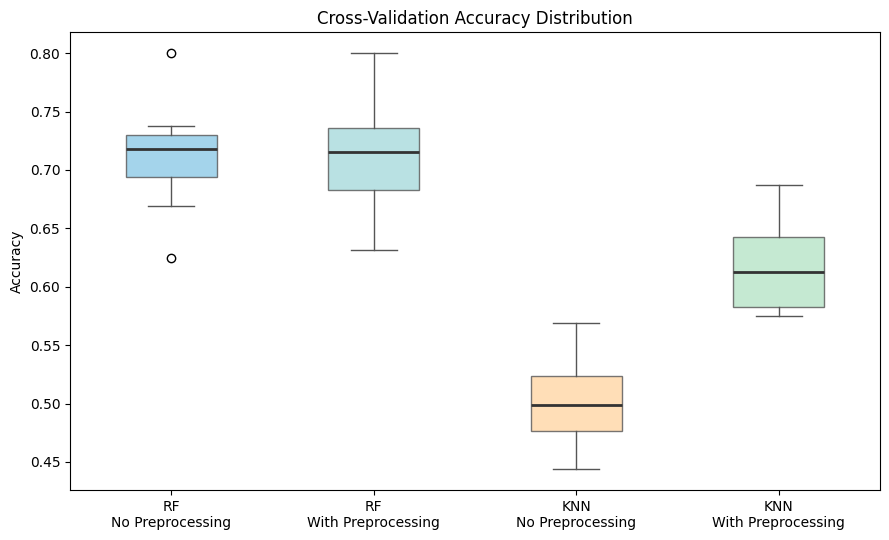

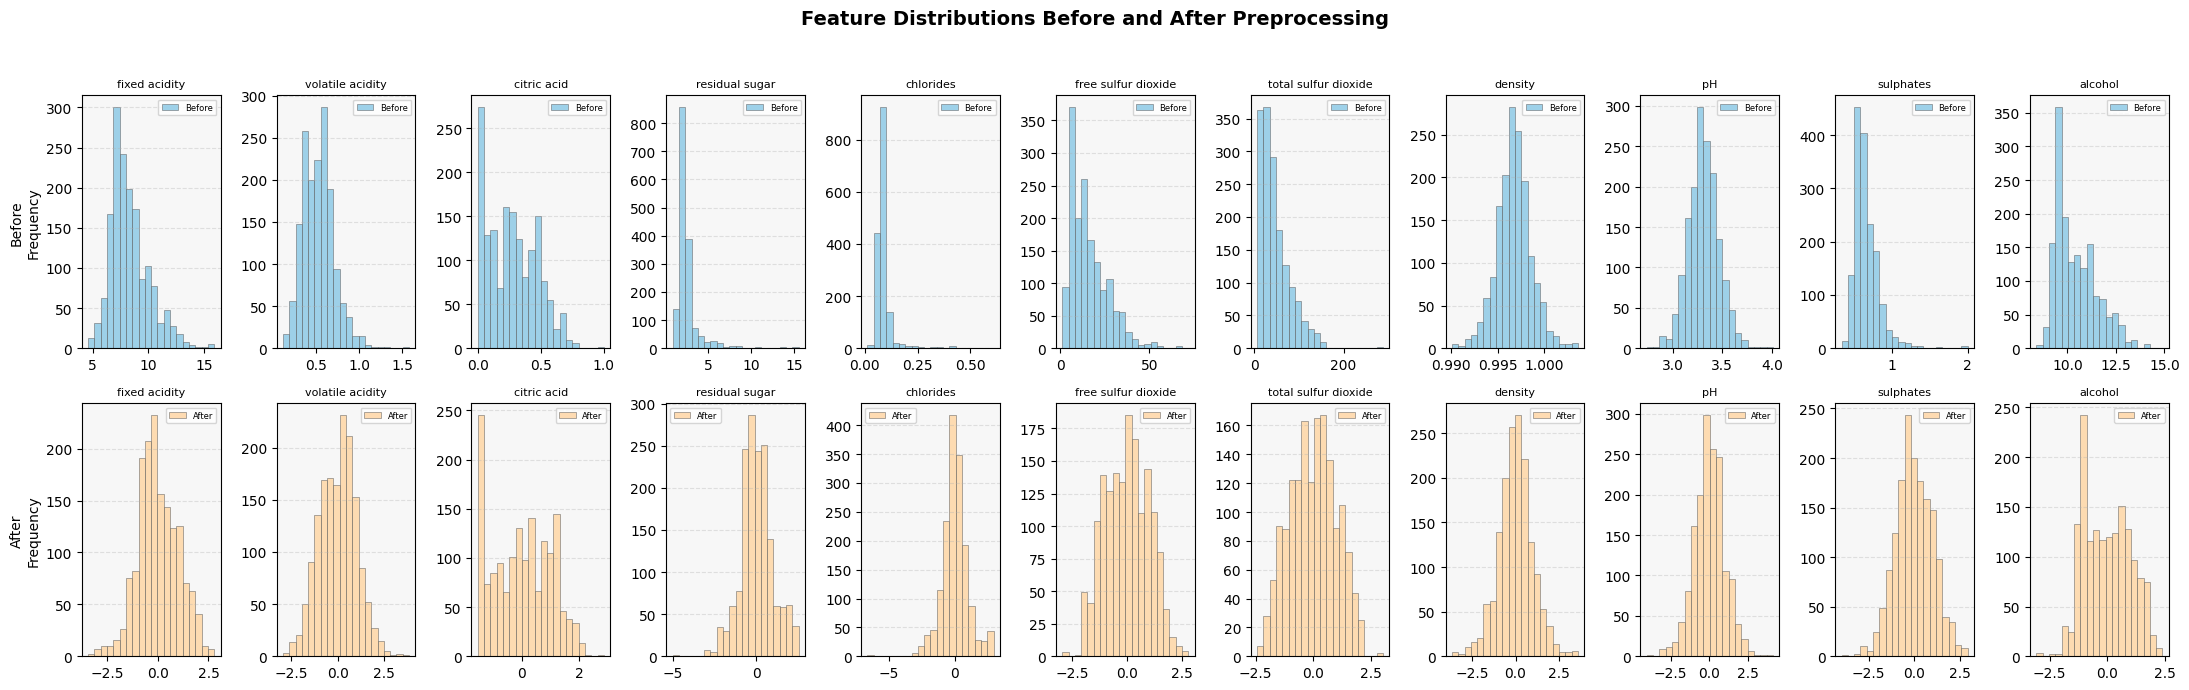

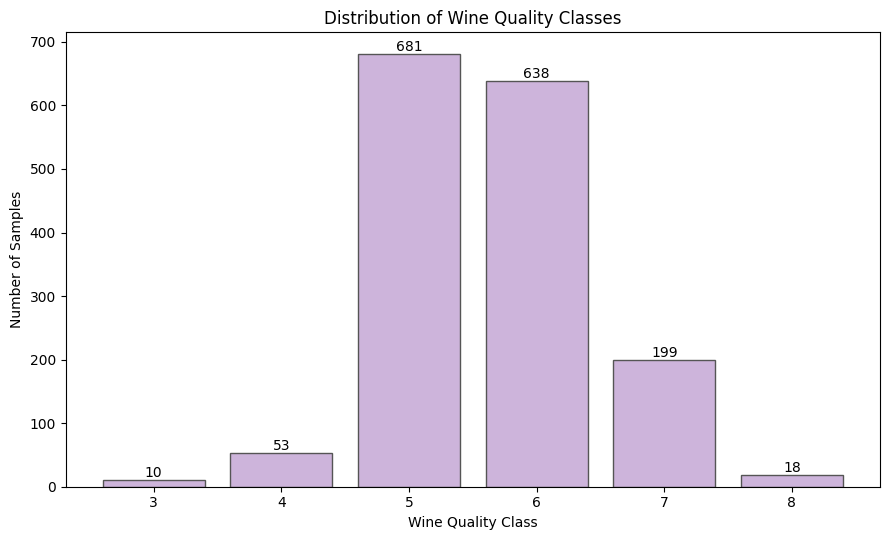

In [9]:
# Model accuracy bar plot


plt.figure(figsize=(9, 5.5))

labels = [
    "RF\nNo Preprocessing",
    "RF\nWith Preprocessing",
    "KNN\nNo Preprocessing",
    "KNN\nWith Preprocessing"
]

scores = [
    rf_scores_no_preprocessing.mean(),
    rf_scores_with_preprocessing.mean(),
    knn_scores_no_preprocessing.mean(),
    knn_scores_with_preprocessing.mean()
]

bars = plt.bar(
    labels,
    scores,
    color=model_colors,
    edgecolor="#555555",
    linewidth=1
)

plt.ylabel("Mean Accuracy")
plt.title("Model Performance With and Without Preprocessing")
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.012,
        f"{score:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()



# Accuracy comparison


model_names = ["Random Forest", "KNN"]

no_preprocessing_scores = [
    rf_scores_no_preprocessing.mean(),
    knn_scores_no_preprocessing.mean()
]

with_preprocessing_scores = [
    rf_scores_with_preprocessing.mean(),
    knn_scores_with_preprocessing.mean()
]

x = np.arange(len(model_names))
width = 0.34

plt.figure(figsize=(9, 5.5))

bars1 = plt.bar(
    x - width / 2,
    no_preprocessing_scores,
    width,
    label="No Preprocessing",
    color=soft_gray,
    edgecolor="#555555",
    linewidth=1
)

bars2 = plt.bar(
    x + width / 2,
    with_preprocessing_scores,
    width,
    label="With Preprocessing",
    color=soft_green,
    edgecolor="#555555",
    linewidth=1
)

plt.xticks(x, model_names)
plt.ylabel("Mean Accuracy")
plt.title("Accuracy Comparison by Model")
plt.ylim(0, 1)
plt.legend()

for bar, score in zip(bars1, no_preprocessing_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.012,
        f"{score:.4f}",
        ha="center",
        fontsize=10
    )

for bar, score in zip(bars2, with_preprocessing_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.012,
        f"{score:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# Cross val score


cv_data = [
    rf_scores_no_preprocessing,
    rf_scores_with_preprocessing,
    knn_scores_no_preprocessing,
    knn_scores_with_preprocessing
]

cv_labels = [
    "RF\nNo Preprocessing",
    "RF\nWith Preprocessing",
    "KNN\nNo Preprocessing",
    "KNN\nWith Preprocessing"
]

plt.figure(figsize=(9, 5.5))

box = plt.boxplot(
    cv_data,
    labels=cv_labels,
    patch_artist=True
)

for patch, color in zip(box["boxes"], model_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor("#555555")

for median in box["medians"]:
    median.set_color("#333333")
    median.set_linewidth(2)

for whisker in box["whiskers"]:
    whisker.set_color("#555555")

for cap in box["caps"]:
    cap.set_color("#555555")

plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy Distribution")
plt.tight_layout()
plt.show()



# Feature distributions

X_transformed = preprocessor.fit_transform(X_red)

fig, axs = plt.subplots(
    2,
    len(features),
    figsize=(22, 7),
    sharey=False
)

before_color = soft_blue
after_color = soft_orange

for i, feature in enumerate(features):
    axs[0, i].hist(
        X_red[feature],
        bins=20,
        color=before_color,
        alpha=0.85,
        edgecolor="#555555",
        linewidth=0.4,
        label="Before"
    )

    axs[1, i].hist(
        X_transformed[:, i],
        bins=20,
        color=after_color,
        alpha=0.85,
        edgecolor="#555555",
        linewidth=0.4,
        label="After"
    )

    axs[0, i].set_title(feature, fontsize=8)
    axs[1, i].set_title(feature, fontsize=8)

    axs[0, i].set_facecolor("#F7F7F7")
    axs[1, i].set_facecolor("#F7F7F7")

    axs[0, i].grid(axis="y", linestyle="--", alpha=0.35)
    axs[1, i].grid(axis="y", linestyle="--", alpha=0.35)

    axs[0, i].legend(fontsize=6)
    axs[1, i].legend(fontsize=6)

axs[0, 0].set_ylabel("Before\nFrequency")
axs[1, 0].set_ylabel("After\nFrequency")

plt.suptitle(
    "Feature Distributions Before and After Preprocessing",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



# distribution


quality_counts = y_red.value_counts().sort_index()

plt.figure(figsize=(9, 5.5))

bars = plt.bar(
    quality_counts.index.astype(str),
    quality_counts.values,
    color=soft_purple,
    edgecolor="#555555",
    linewidth=1
)

plt.xlabel("Wine Quality Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Wine Quality Classes")

for bar, count in zip(bars, quality_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 5,
        str(count),
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()